# CPLEX RCW surrogate: fixed-depth analytics

This notebook compares maximum SMAC random-forest depths 5, 10, 15, 20, and 30 across three SMAC seeds. Because the runs may still be active, every comparison is truncated to the minimum number of completed target trials across all 15 depth–seed runs at the moment the data-loading cell is executed.

In [10]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

HERE = Path.cwd().resolve()
if not (HERE / 'results').is_dir():
    HERE = (Path.cwd() / 'experiments/aclib/cplex_rcw_surrogate/01_initial_cr').resolve()
ACLIB_ROOT = HERE.parents[1]
if str(ACLIB_ROOT) not in sys.path:
    sys.path.insert(0, str(ACLIB_ROOT))

from surrogate_analytics import (
    DEPTHS,
    SMAC_SEEDS,
    build_analysis_bundle,
    plot_final_incumbents,
    plot_incumbent_confidence_intervals,
    plot_incumbents_by_seed,
    plot_selected_seed_diagnostics,
    write_analysis_tables,
)

BENCHMARK_KEY = 'cplex_rcw'
SELECTED_SMAC_SEED = 1
VALIDATION_QUANTILE_SEED = 0
plt.rcParams.update({'figure.dpi': 120, 'axes.grid': False})
print('Experiment:', HERE)

Experiment: /rwthfs/rz/cluster/home/io632776/experiments/adaptive-smac/experiments/aclib/cplex_rcw_surrogate/01_initial_cr


## Common horizon and validation definition

The loader snapshots all current run histories and selects their minimum completed-trial count as the common horizon. Incumbent events and proposal diagnostics after that horizon are excluded. Each retained configuration is independently evaluated on **every training instance** using ACLib quantile seed 0, which returns the deterministic median. The plotted objective is mean PAR10 across those training instances; ACLib test instances remain unused. Results are cached by configuration fingerprint, so later reruns validate only newly encountered configurations.

In [11]:
bundle = build_analysis_bundle(
    HERE,
    BENCHMARK_KEY,
    selected_seed=SELECTED_SMAC_SEED,
    validation_quantile_seed=VALIDATION_QUANTILE_SEED,
    trial_limit='minimum',
)
table_files = write_analysis_tables(bundle)
availability = (
    bundle.final_incumbents.assign(common_horizon=bundle.n_trials)
    .pivot(index='depth', columns='smac_seed', values='common_horizon')
)
display(availability)
print(f'Common analysis horizon: {bundle.n_trials:,} completed trials per run.')
print(
    f'Loaded 15 comparable run snapshots; '
    f'{bundle.training_instance_count} training instances; '
    f'{len(bundle.proposal_diagnostics)} trained proposals through the horizon '
    f'for seed {SELECTED_SMAC_SEED}.'
)
print('Validation cache:', bundle.validation_cache_file)
print('Exported tables:')
for path in table_files:
    print(' ', path)

Validating 1079 new configurations on all 495 training instances (quantile seed 0).
  validated 100/1079 new configurations in 3.3s
  validated 200/1079 new configurations in 6.2s
  validated 300/1079 new configurations in 9.0s
  validated 400/1079 new configurations in 12.2s
  validated 500/1079 new configurations in 15.0s
  validated 600/1079 new configurations in 16.5s
  validated 700/1079 new configurations in 18.2s
  validated 800/1079 new configurations in 19.8s
  validated 900/1079 new configurations in 22.5s
  validated 1000/1079 new configurations in 24.1s
  validated 1079/1079 new configurations in 25.5s


smac_seed,0,1,2
depth,,,
5,1741,1741,1741
10,1741,1741,1741
15,1741,1741,1741
20,1741,1741,1741
30,1741,1741,1741


Common analysis horizon: 1,741 completed trials per run.
Loaded 15 comparable run snapshots; 495 training instances; 1280 trained proposals through the horizon for seed 1.
Validation cache: /rwthfs/rz/cluster/home/io632776/experiments/adaptive-smac/experiments/aclib/cplex_rcw_surrogate/01_initial_cr/analytics_cache/full_training_validation_qseed_0.json
Exported tables:
  /rwthfs/rz/cluster/home/io632776/experiments/adaptive-smac/experiments/aclib/cplex_rcw_surrogate/01_initial_cr/analytics_cache/incumbent_trajectory_events.csv
  /rwthfs/rz/cluster/home/io632776/experiments/adaptive-smac/experiments/aclib/cplex_rcw_surrogate/01_initial_cr/analytics_cache/final_incumbents.csv
  /rwthfs/rz/cluster/home/io632776/experiments/adaptive-smac/experiments/aclib/cplex_rcw_surrogate/01_initial_cr/analytics_cache/selected_seed_proposal_diagnostics.csv
  /rwthfs/rz/cluster/home/io632776/experiments/adaptive-smac/experiments/aclib/cplex_rcw_surrogate/01_initial_cr/analytics_cache/selected_seed_ei_bat

## 1. Incumbent trajectory for each SMAC seed

Each figure fixes one SMAC seed and compares all five RF depths through the common horizon. A step changes exactly when SMAC's recorded incumbent changes; its height is that configuration's independently calculated mean PAR10 over all training instances. The first three figures use a linear performance axis and the following three repeat the same data on a logarithmic performance axis.

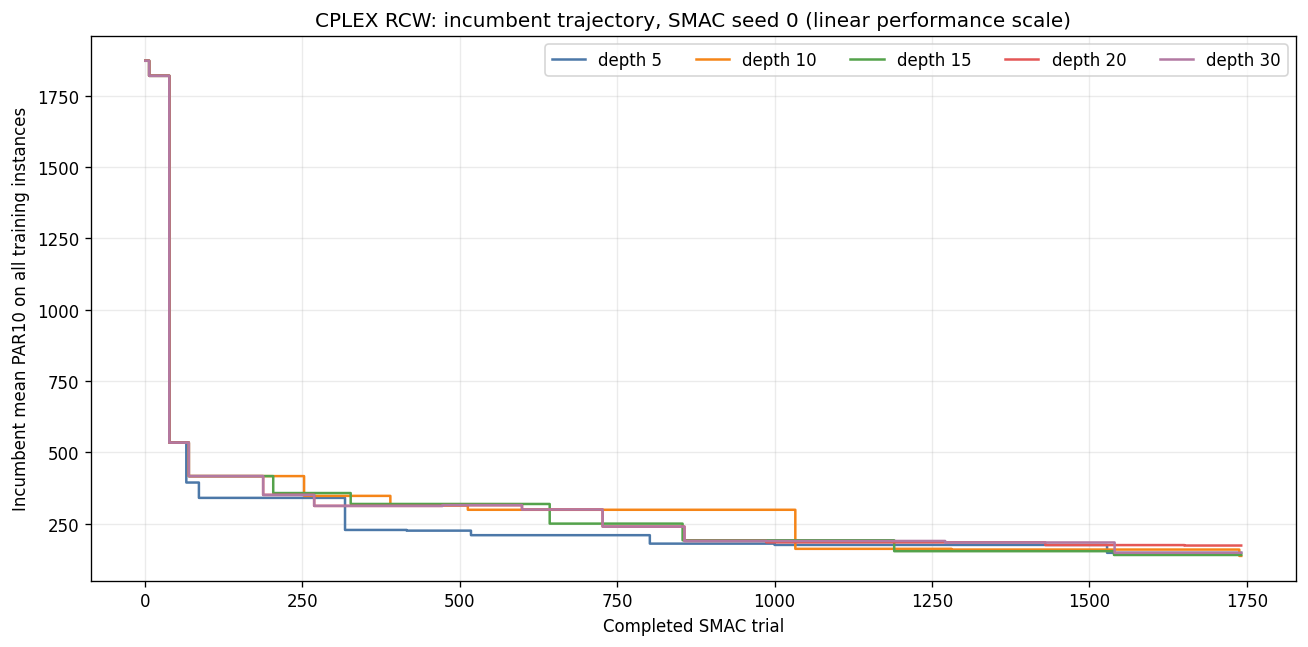

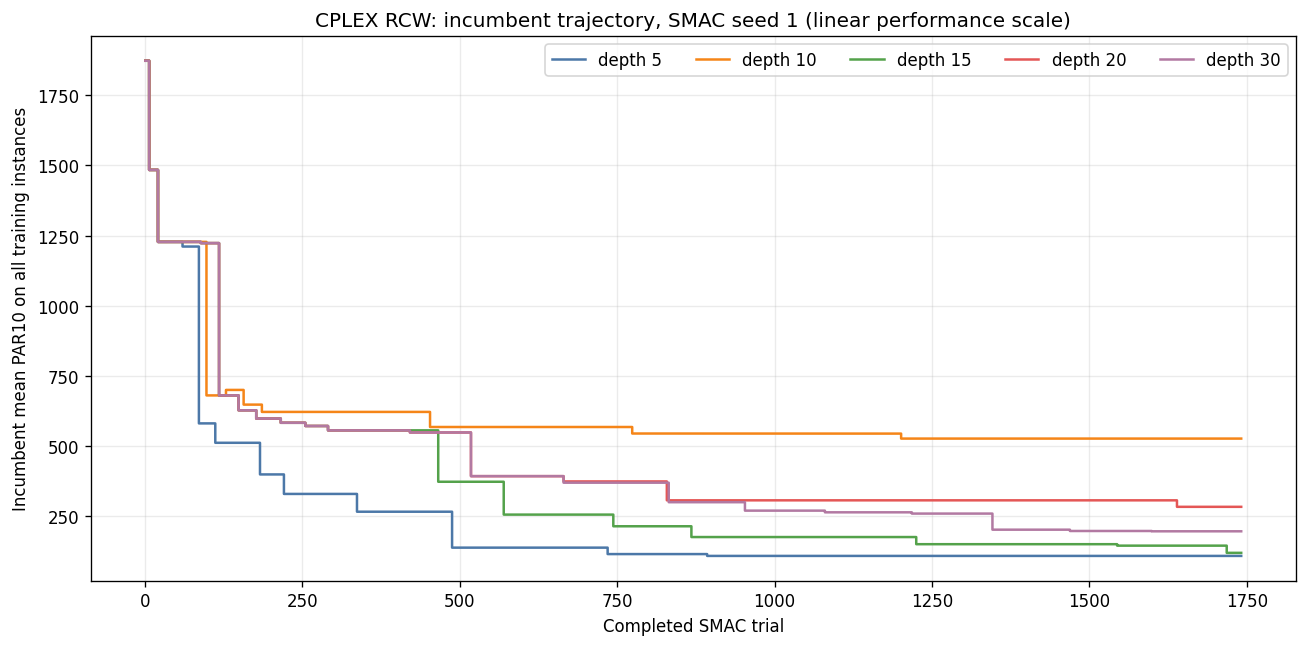

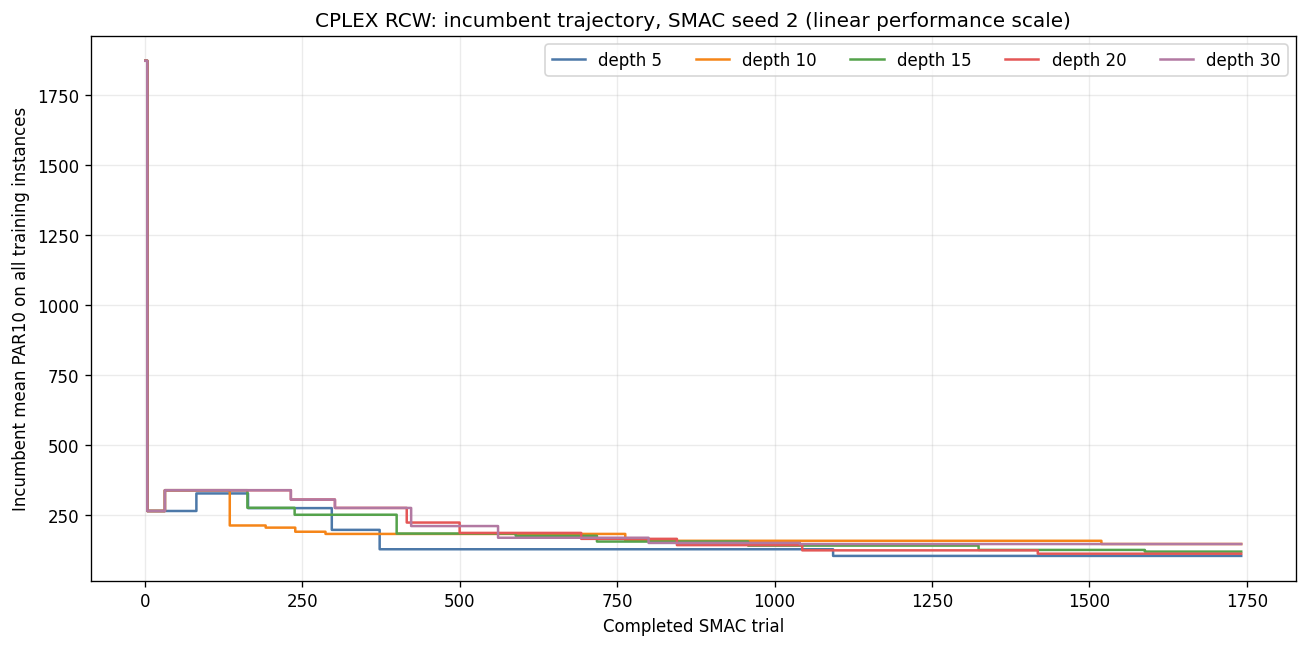

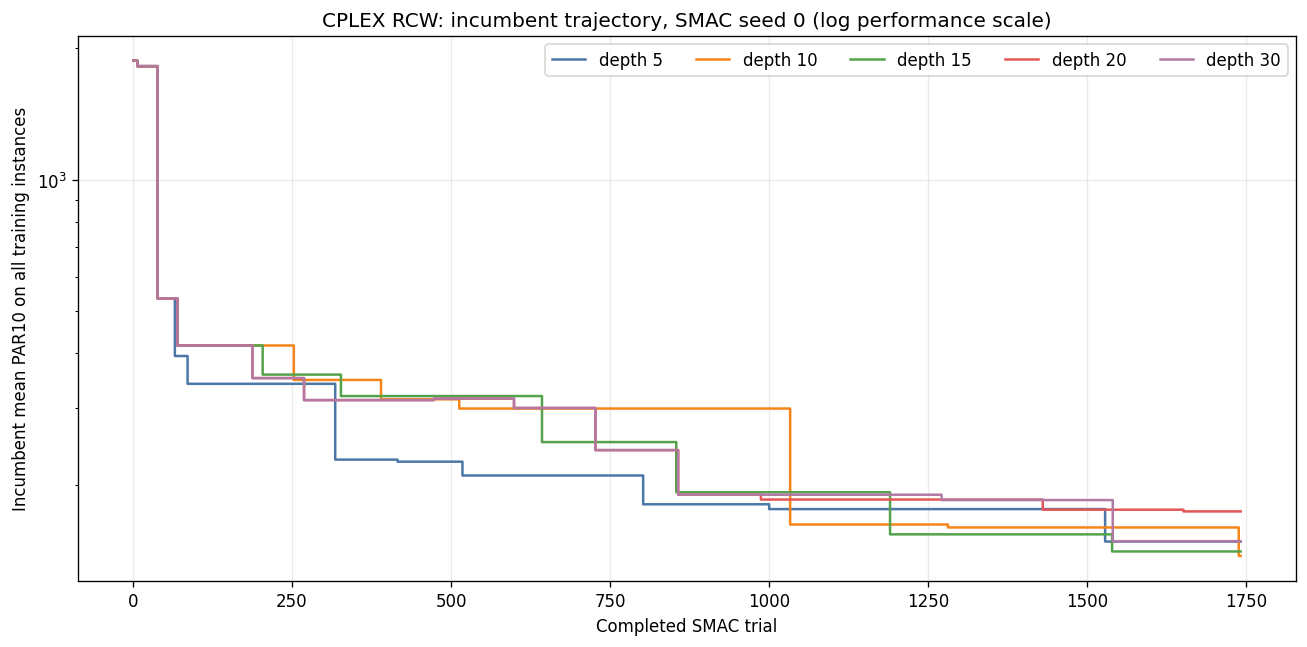

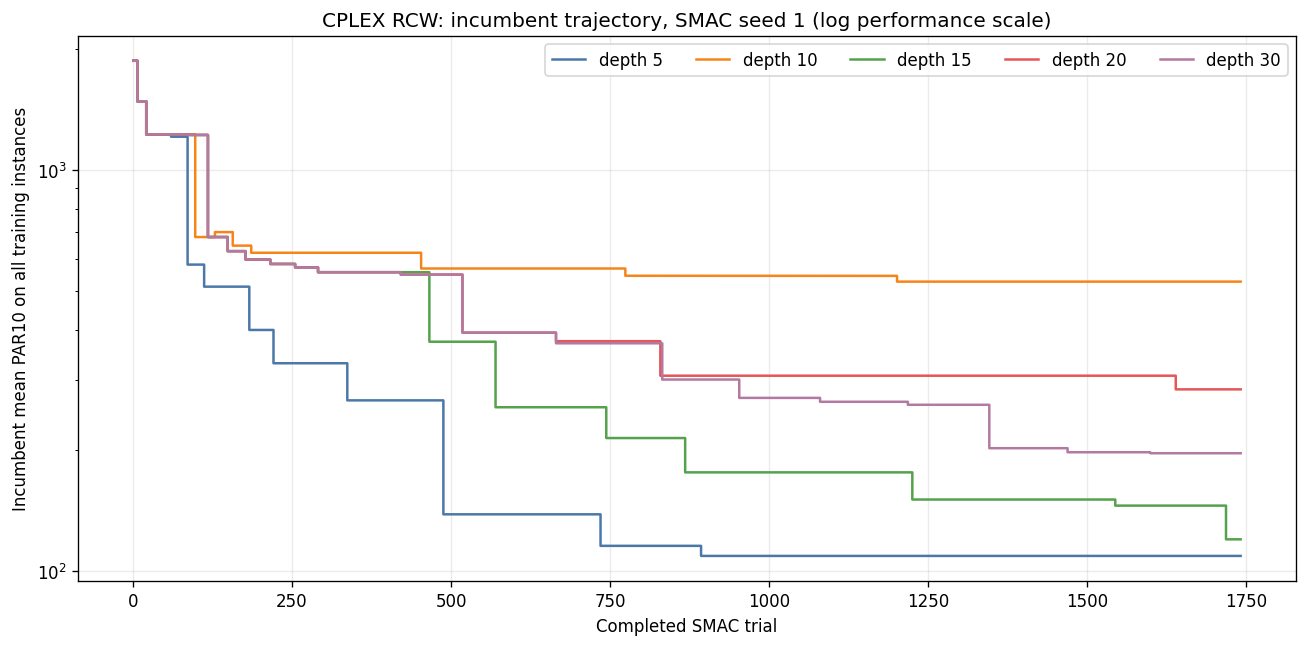

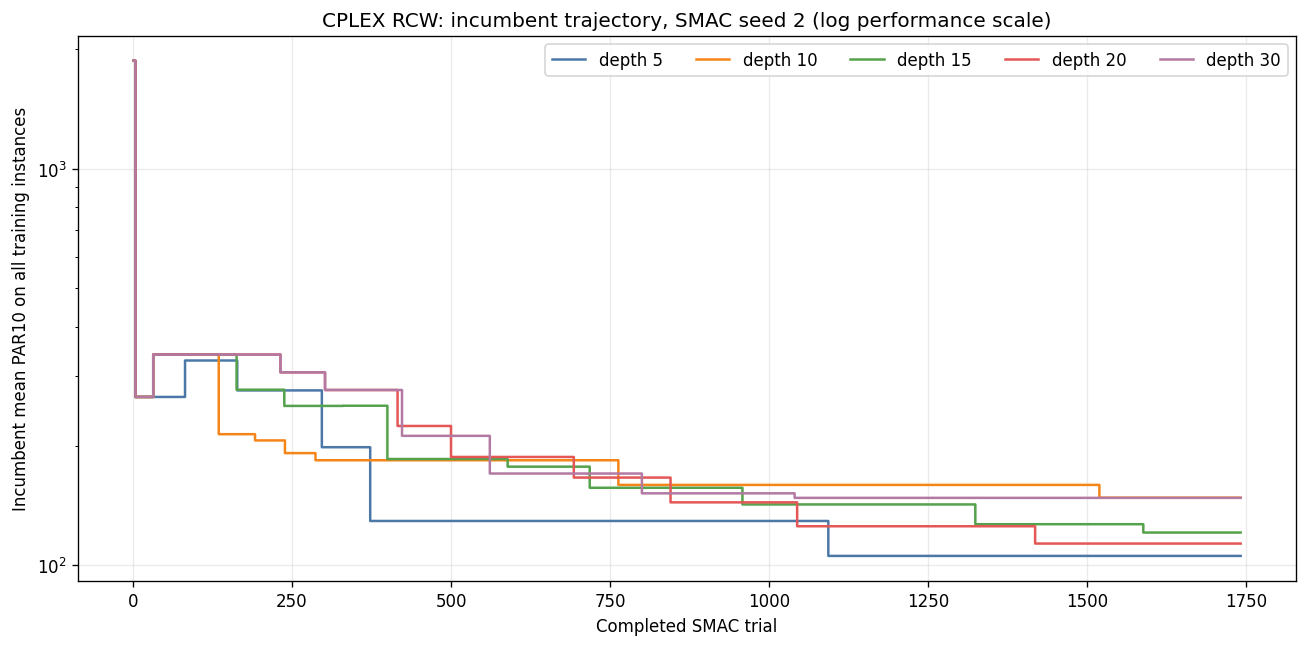

In [12]:
seed_figures = plot_incumbents_by_seed(bundle)
plt.show()

log_seed_figures = plot_incumbents_by_seed(bundle, yscale='log')
plt.show()

## 2. Incumbent trajectory averaged over SMAC seeds

For each depth, the line is the pointwise arithmetic mean of the three independently validated incumbent trajectories. The shaded band is a two-sided 95% Student-*t* confidence interval across the three SMAC seeds. With only three seeds, it has two degrees of freedom and should be interpreted cautiously.

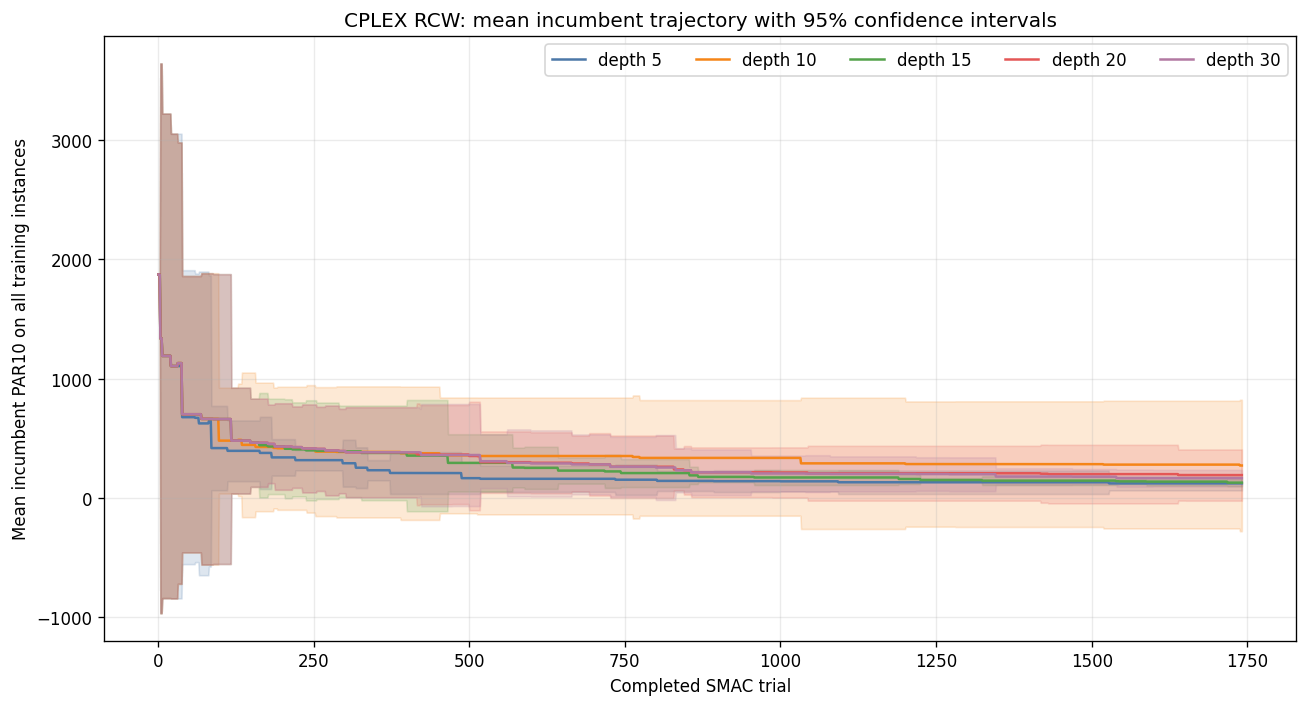

In [13]:
confidence_figure = plot_incumbent_confidence_intervals(bundle)
plt.show()

## 2b. Best incumbent depth within each 500-trial window

For every trial, the depth with the lowest independently validated incumbent PAR10 receives one unit of credit. Exact ties split that credit equally, avoiding arbitrary tie-breaking. The first three grouped-bar figures show individual SMAC seeds; the fourth is the arithmetic mean of the counts across seeds. Complete windows contain 500 credits, while the final partial window contains exactly its displayed number of trials. These are occupancy counts, not counts of incumbent changes.

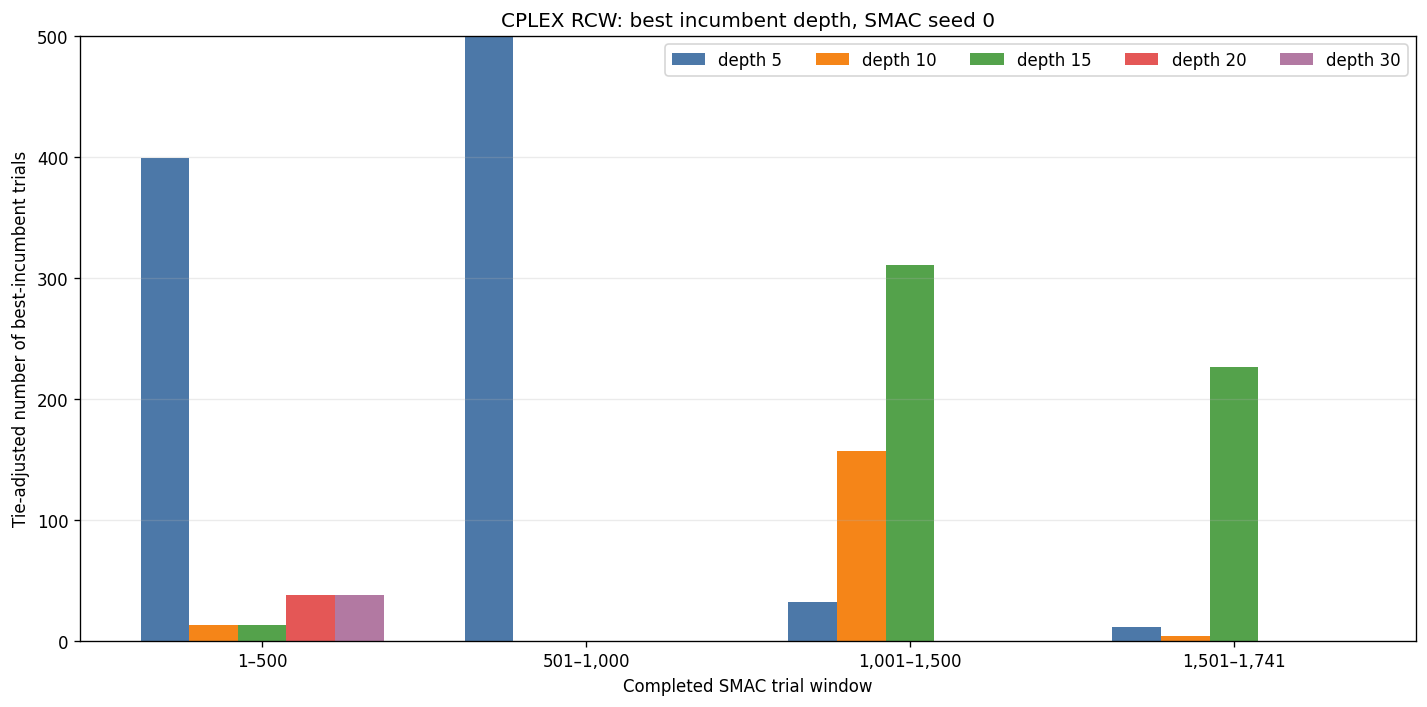

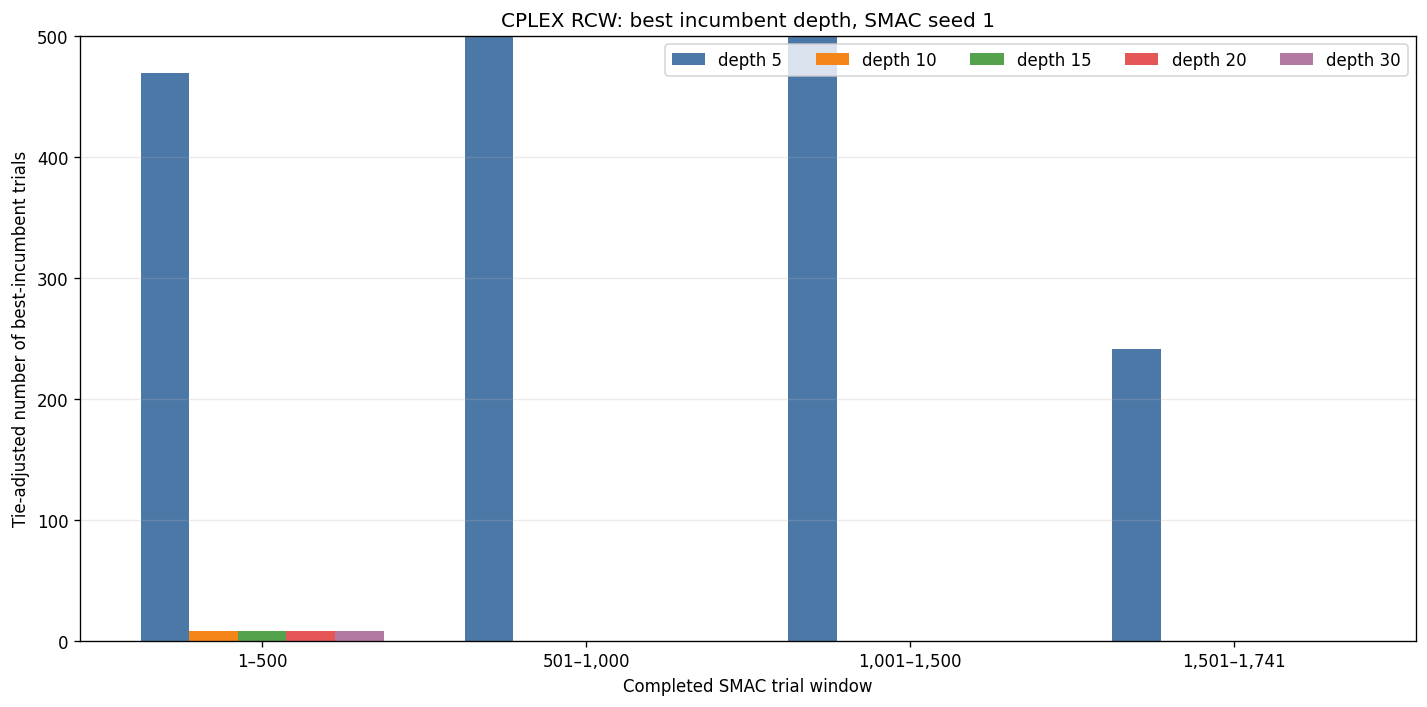

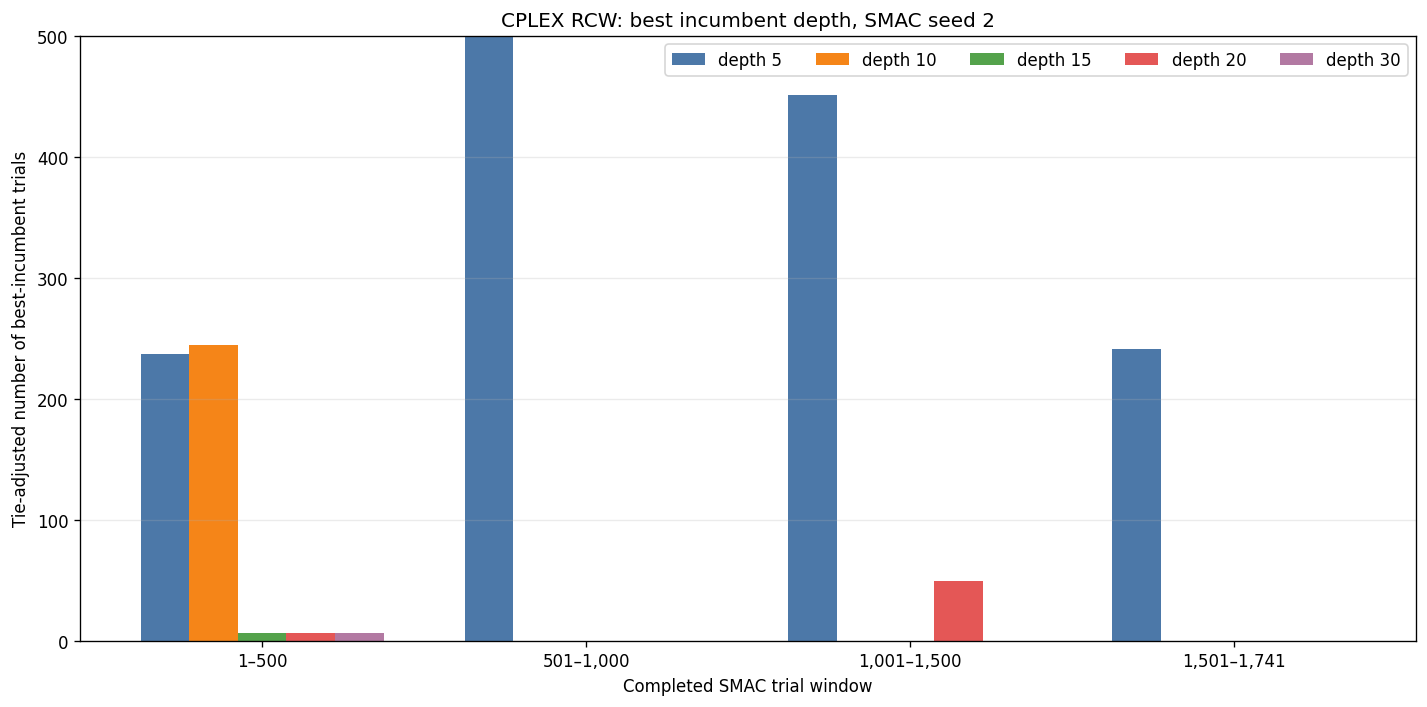

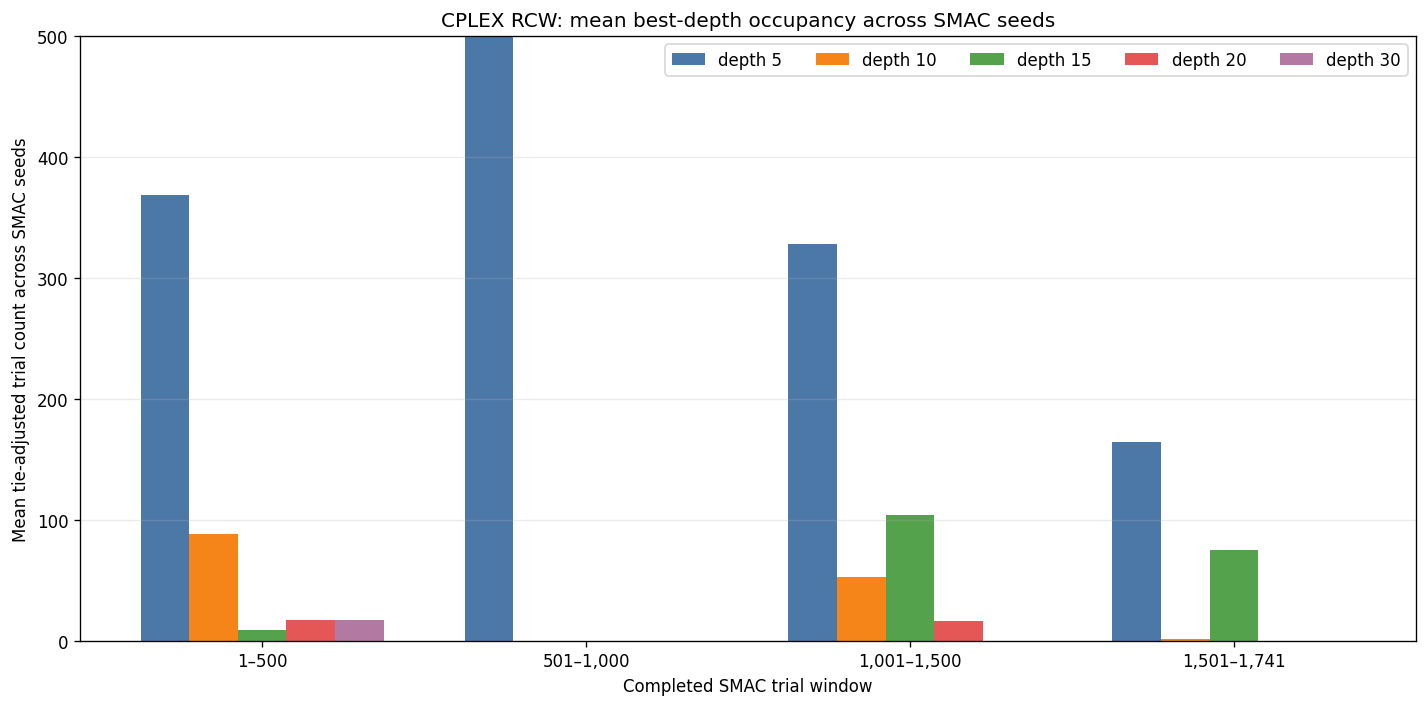

In [14]:
import numpy as np

WINDOW_SIZE = 500
WINDOW_STARTS = np.arange(0, bundle.n_trials, WINDOW_SIZE)
WINDOW_ENDS = np.minimum(WINDOW_STARTS + WINDOW_SIZE, bundle.n_trials)
WINDOW_LABELS = [
    f'{start + 1:,}–{end:,}'
    for start, end in zip(WINDOW_STARTS, WINDOW_ENDS)
]
DEPTH_COLORS = {5: '#4c78a8', 10: '#f58518', 15: '#54a24b', 20: '#e45756', 30: '#b279a2'}

def incumbent_values_for_seed(smac_seed):
    trial_grid = np.arange(1, bundle.n_trials + 1)
    depth_values = []
    for depth in DEPTHS:
        events = bundle.trajectory_events[
            (bundle.trajectory_events['depth'] == depth)
            & (bundle.trajectory_events['smac_seed'] == smac_seed)
        ].sort_values('trial').drop_duplicates('trial', keep='last')
        event_trials = events['trial'].to_numpy(dtype=int)
        event_values = events['full_training_par10'].to_numpy(dtype=float)
        positions = np.searchsorted(event_trials, trial_grid, side='right') - 1
        if np.any(positions < 0):
            raise RuntimeError('An incumbent trajectory does not start at trial 1.')
        depth_values.append(event_values[positions])
    return np.vstack(depth_values)

def best_depth_counts_for_seed(smac_seed):
    values = incumbent_values_for_seed(smac_seed)
    best_values = np.min(values, axis=0, keepdims=True)
    tied = np.isclose(values, best_values, rtol=1e-10, atol=1e-12)
    credit = tied / tied.sum(axis=0, keepdims=True)
    counts = np.vstack([
        credit[:, start:end].sum(axis=1)
        for start, end in zip(WINDOW_STARTS, WINDOW_ENDS)
    ])
    expected = WINDOW_ENDS - WINDOW_STARTS
    if not np.allclose(counts.sum(axis=1), expected):
        raise RuntimeError('Tie-adjusted window counts have incorrect totals.')
    return counts

def plot_best_depth_counts(counts, title, ylabel):
    figure, axis = plt.subplots(figsize=(12, 6))
    groups = np.arange(len(WINDOW_STARTS))
    width = 0.15
    for index, depth in enumerate(DEPTHS):
        axis.bar(groups + (index - 2) * width, counts[:, index], width=width,
                 color=DEPTH_COLORS[depth], label=f'depth {depth}')
    axis.set(xticks=groups, xticklabels=WINDOW_LABELS,
             xlabel='Completed SMAC trial window', ylabel=ylabel,
             title=title, ylim=(0, WINDOW_SIZE))
    axis.grid(axis='y', alpha=0.25)
    axis.legend(ncol=len(DEPTHS))
    figure.tight_layout()
    return figure

best_depth_counts = {seed: best_depth_counts_for_seed(seed) for seed in SMAC_SEEDS}
for seed in SMAC_SEEDS:
    plot_best_depth_counts(best_depth_counts[seed],
                           f'{bundle.display_name}: best incumbent depth, SMAC seed {seed}',
                           'Tie-adjusted number of best-incumbent trials')
    plt.show()

mean_best_depth_counts = np.mean(np.stack(list(best_depth_counts.values())), axis=0)
plot_best_depth_counts(mean_best_depth_counts,
                       f'{bundle.display_name}: mean best-depth occupancy across SMAC seeds',
                       'Mean tie-adjusted trial count across SMAC seeds')
plt.show()

## 3. Incumbent performance at the common horizon by RF depth

The x-axis is configured maximum RF depth and the y-axis is the incumbent's mean PAR10 over every training instance at the shared trial horizon. There are exactly three points per depth—one per SMAC seed. Horizontal offsets only prevent overlapping markers.

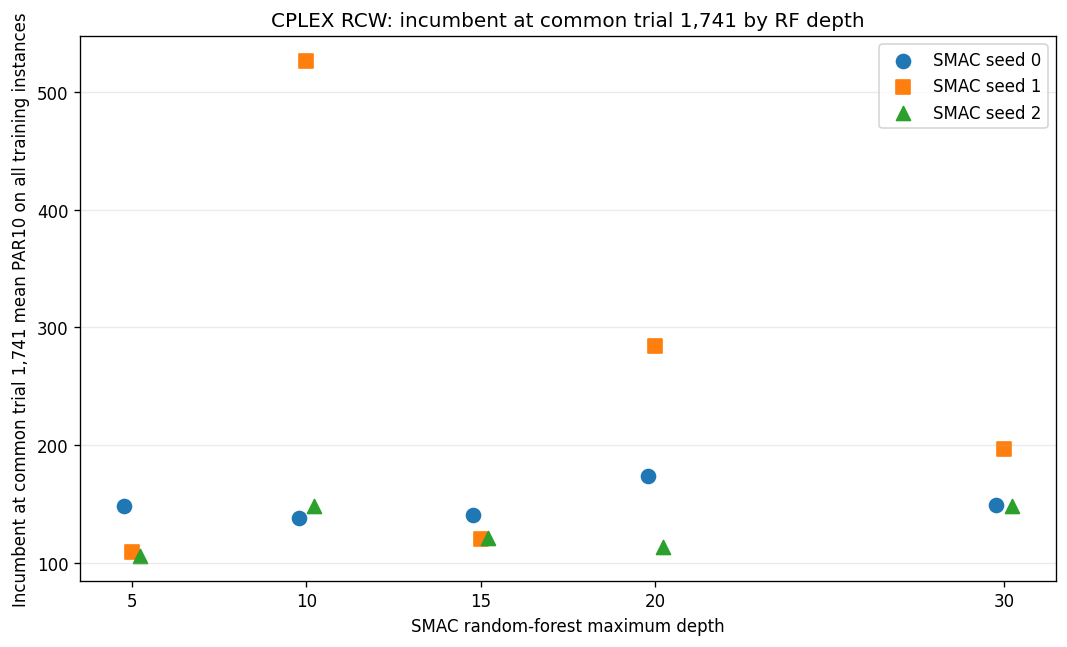

,depth,smac_seed,trial,full_training_par10,config_id
0,5,0,1741,148.313080,226
1,5,1,1741,109.138049,141
2,5,2,1741,105.660710,275
3,10,0,1741,137.513555,215
4,10,1,1741,526.929423,174
5,10,2,1741,148.153983,295
6,15,0,1741,140.781367,230
7,15,1,1741,120.035284,171
8,15,2,1741,121.016628,212
9,20,0,1741,173.883677,208


In [15]:
final_figure = plot_final_incumbents(bundle)
plt.show()
display(bundle.final_incumbents[
    ['depth', 'smac_seed', 'trial', 'full_training_par10', 'config_id']
].sort_values(['depth', 'smac_seed']))

## 4. Aligned model and optimization diagnostics for one SMAC seed

The eight panels use SMAC seed 0 and overlay all depths through the common horizon: independently validated incumbent; exact EI of each evaluated trained-model proposal; RF-predicted performance marginalized over training instances; predictive variance; absolute validation error; signed standardized error `(validation − prediction) / predicted standard deviation`; average actual depth across the 100 RF trees; and population variance of EI among proposals selected from one RF fit.

The last panel is only a **selected-proposal EI variance**. Telemetry retained the configurations SMAC selected for evaluation (normally up to eight per fit), but not every discarded random challenger or local-search neighbor considered internally. Therefore the full acquisition-search-pool EI variance cannot be reconstructed exactly from these runs. Prediction-error panels are retrospective because all-instance validation was not available to SMAC online.

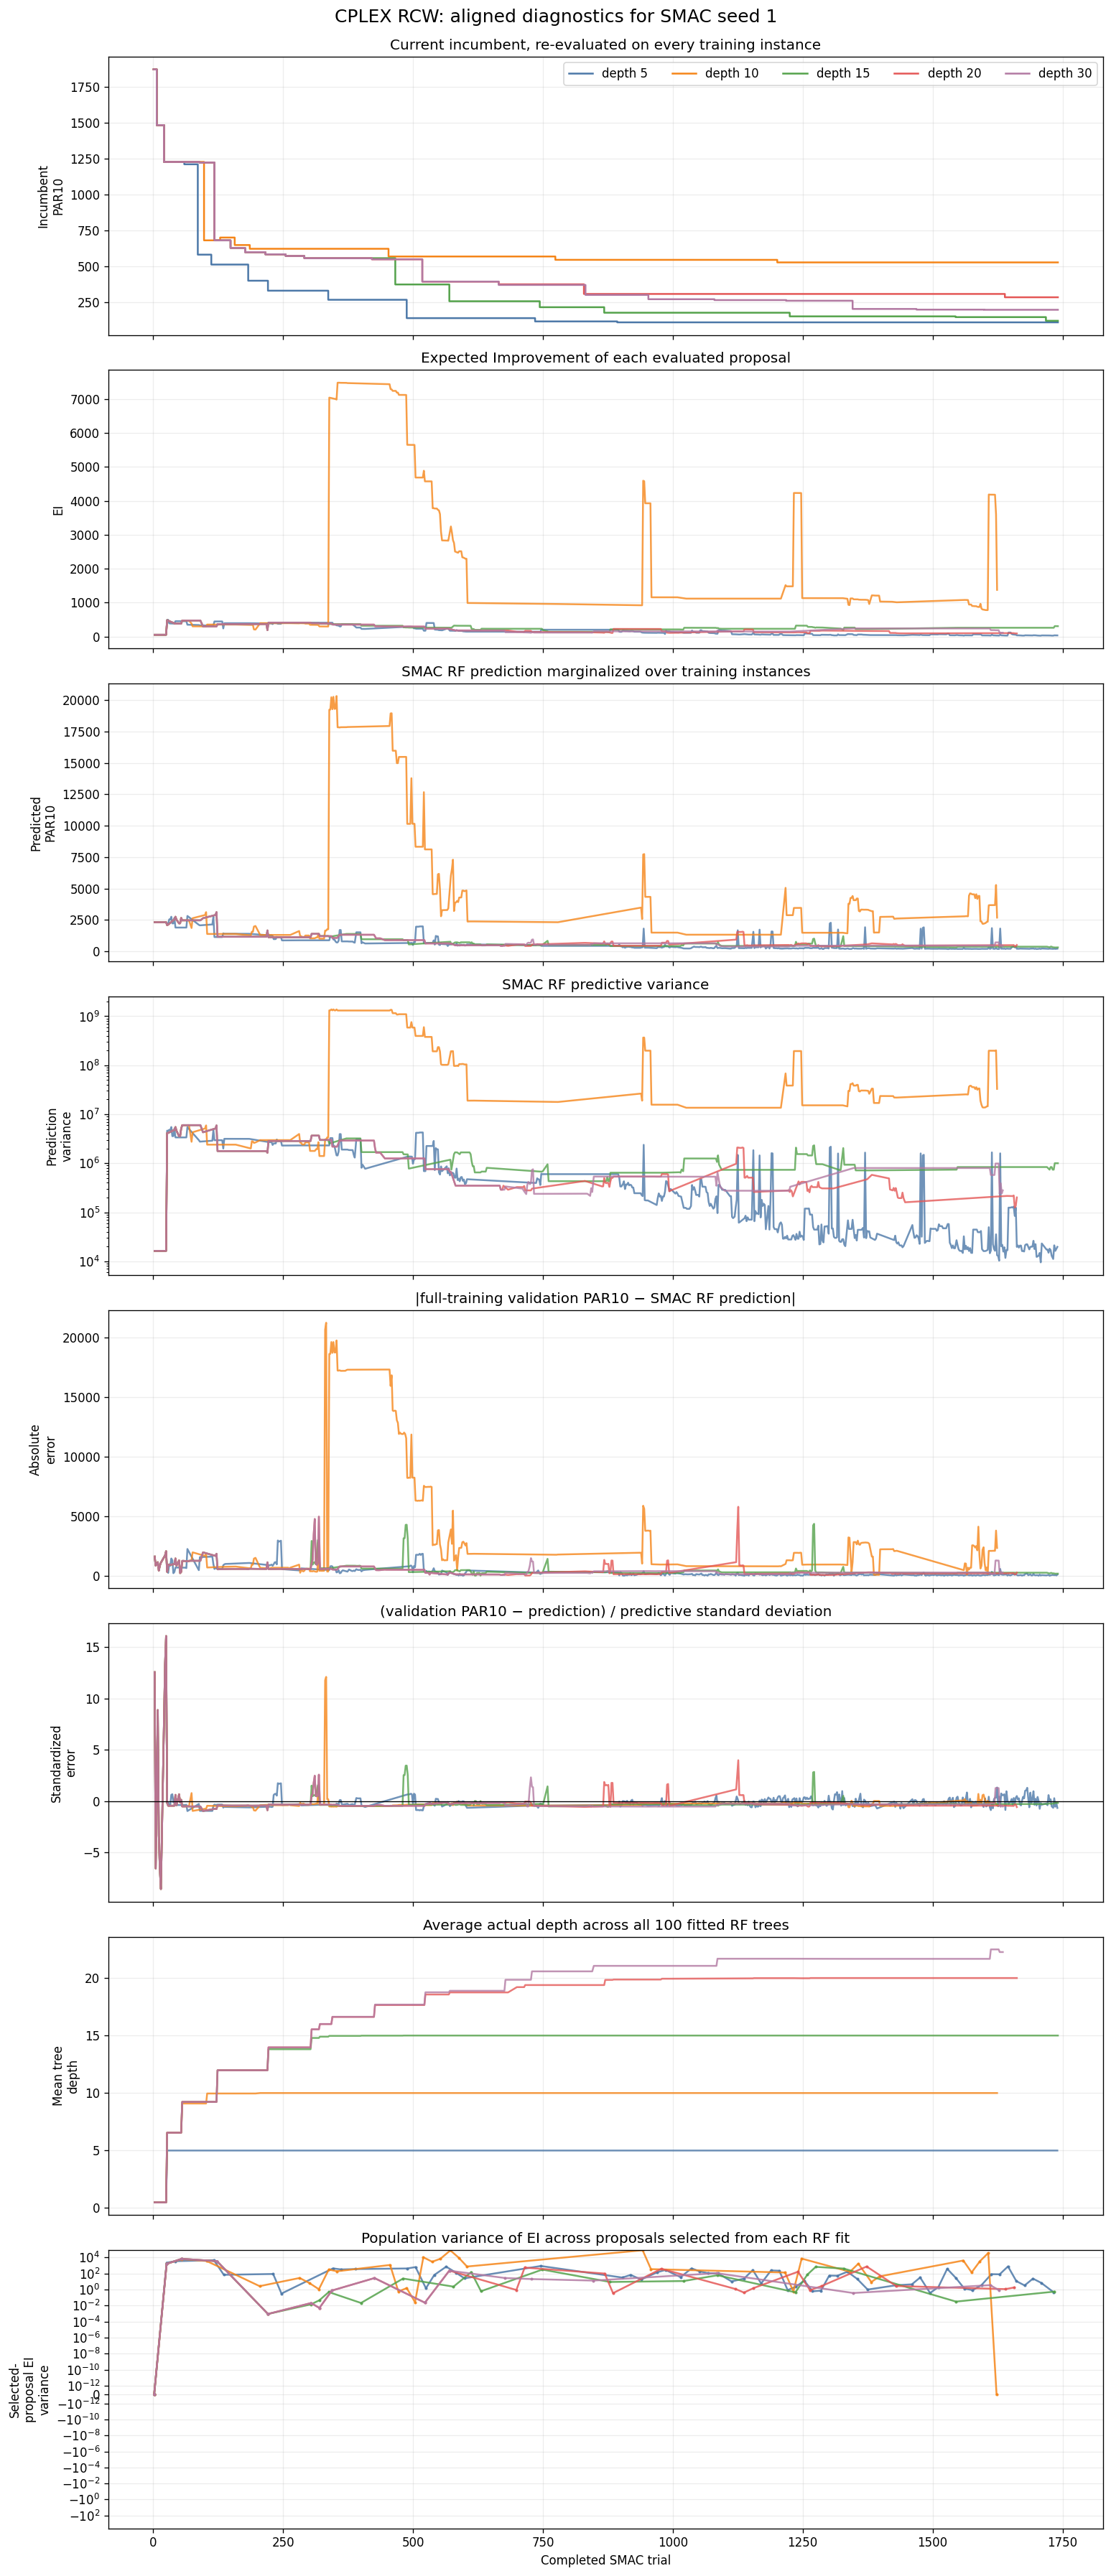

In [16]:
diagnostic_figure = plot_selected_seed_diagnostics(
    bundle,
    selected_seed=SELECTED_SMAC_SEED,
)
plt.show()

## Diagnostic coverage table

This table reports how many trained-model proposals and distinct RF fits contribute to the seed-0 diagnostic panels through the common horizon. Mean absolute and standardized errors summarize retrospective all-instance validation; `mean_selected_per_fit` states how many selected proposals contribute to each recorded EI-variance estimate.

In [17]:
coverage = (
    bundle.proposal_diagnostics.groupby('depth')
    .agg(
        trained_proposals=('configuration_fingerprint', 'size'),
        rf_fits=('fit_serial', 'nunique'),
        mean_absolute_error=('absolute_error', 'mean'),
        mean_standardized_error=('standardized_error', 'mean'),
    )
)
selected_counts = (
    bundle.ei_batch_variance.groupby('depth')['selected_proposal_count']
    .mean().rename('mean_selected_per_fit')
)
display(coverage.join(selected_counts))

,trained_proposals,rf_fits,mean_absolute_error,mean_standardized_error,mean_selected_per_fit
depth,,,,,
5,492,62,254.979001,-0.064263,7.935484
10,265,34,3980.326817,-0.077288,7.794118
15,180,23,697.231034,0.017043,7.826087
20,203,26,562.318606,0.037494,7.807692
30,140,18,659.120262,0.048989,7.777778
